In [1]:
from julia.api import Julia
from julia import Main

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

import scipy.special as sp
import os
import sys

from pathlib import Path
import shutil

sys.path.insert(0, str(Path("../JAMDiFF_library").resolve()))
from get_JAM_DiFF import get_JAM_DiFF_dict

import pickle

# Parameter-only prediction notebook

Copied from `predict_rand_CT18.ipynb`. This version fixes JAM DiFF replica `0` and CT18 PDF member `0`, samples only model/shape parameters, and does not write `pkl` plot-data files.


Settings

In [2]:
c = 1/2

fit_name = "Default"

if_generate_grids = False

N_cores = 8

draw_chunk_size = 32

sidis_plot_n_points = 45
ee_aut_plot_n_points = 45
ee_eec_plot_n_points = 45

chi_deg_range = (0.1, 45.0)

# Scale branches included in the last SIDIS EEC block.
sidis_eec_scale_labels = ["Q"]


Read Files

In [3]:
Main.eval('using Distributed')
existing_workers = list(Main.eval('workers()'))
if existing_workers:
    Main.eval('rmprocs(workers())')
Main.eval(f'addprocs({N_cores})')

fitting_root = "../"
def include(name):
    path = os.path.join(fitting_root, name)
    Main.eval(f'@everywhere include(raw"{path}")')

card_name = fit_name.removesuffix(".jl")
include(f"Cards/{card_name}.jl")

# PDF
include("Collinear_PDF/pdf.jl")
# Core
include("Core/constants.jl")
include("Core/strong coupling.jl")
# Numerical
include("Numerical/FastGK.jl")
# DiFF 
include("DiFF_EEC/DiFF_EEC.jl")
include("Processes/SIDIS/SIDIS_AUT.jl")
include("Processes/ee/ee_AUT.jl")
include("Processes/ee/ee_EEC.jl")

wdir = Main.eval("wdir")
results_dir_name = Main.eval("results_dir_name")
scan_grid_name = str(Main.eval("scan_grid_name"))
scan_coeffs_path = Path(f"{scan_grid_name}.xlsx")
dict_raw_DiFF_name = str(Main.eval("dict_raw_DiFF_name"))
dict_raw_DiFF_path = Path("../Grids") / f"{dict_raw_DiFF_name}.pkl"


┌ Warning: rmprocs: process 1 not removed
└ @ Distributed ~/.julia/juliaup/julia-1.11.6+0.x64.linux.gnu/share/julia/stdlib/v1.11/Distributed/src/cluster.jl:1049


      From worker 6:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/CT18NLO_mc/CT18NLO_mc_0000.dat
      From worker 6:	CT18NLO_mc PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 7:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/CT18NLO_mc/CT18NLO_mc_0000.dat
      From worker 7:	CT18NLO_mc PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 7:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/JAMDiFF23-transversity_lo/JAMDiFF23-transversity_lo_0000.dat
      From worker 7:	JAMDiFF23-transversity_lo PDF set, member #0, version 1; LHAPDF ID = 1
      From worker 2:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/CT18NLO_mc/CT18NLO_mc_0000.dat
      From worker 2:	CT18NLO_mc PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 2:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/DiFF/.runtime/lhapdf-data/JAMDiFF23-transv

Generate JAM DiFFs 

In [4]:
z_array=np.linspace(0.19,0.99,20)  
Mh_array=np.linspace(0.28,2.05,50)
Q_array = [2,3.65,7,8.5,10,10.58]

In [5]:
kinds = ["D1", "H1a"]
mu_array = c*np.array(Q_array)
if if_generate_grids:
    raise RuntimeError("predict_param_only_CT18.ipynb does not generate or store pkl grids; use the original grid notebook if you need to rebuild dict_raw_DiFF.")

with open(dict_raw_DiFF_path, "rb") as f:
    dict_raw_DiFF_full = pickle.load(f)

keys = [k for k in dict_raw_DiFF_full.keys() if isinstance(k, tuple)]


Construct JAM DiFF Interpolators

In [6]:
all_replica_ids = np.asarray(sorted({k[2] for k in keys if k[2] > 0}), dtype=int)
N_total = len(all_replica_ids)

selected_positive_replica_ids = np.asarray([], dtype=int)
replica_ids = np.asarray([0], dtype=int)
selected_replica_set = {0}

# Parameter-only notebook: keep only central JAM replica 0 in the worker payload.
dict_raw_DiFF = {
    k: v for k, v in dict_raw_DiFF_full.items()
    if (not isinstance(k, tuple)) or (k[2] in selected_replica_set)
}
keys = [k for k in dict_raw_DiFF.keys() if isinstance(k, tuple)]
selected_keys = list(keys)

Main.dict_raw_DiFF = dict_raw_DiFF
Main.eval("""let payload = dict_raw_DiFF
    @everywhere global dict_raw_DiFF = $payload
end""")

Main.selected_keys = selected_keys
Main.eval("""let payload = selected_keys
    @everywhere global selected_keys = $payload
end""")

include("Grids/initialization.jl")

del dict_raw_DiFF_full

print(f"Loaded central JAM replica 0 only; ignored {N_total} positive JAM replicas.")


Loaded central JAM replica 0 only; ignored 969 positive JAM replicas.


Test & Warm Up SIDIS AUT

In [7]:
chi_deg = 10.0
chi = np.deg2rad(chi_deg)

Main.a_D1 = 0.1
Main.b_D1 = 0.1
Main.a_H1a = 0.1
Main.b_H1a = 0.1
Main.eval('''@everywhere begin
    global a_D1 = 0.1
    global b_D1 = 0.1
    global a_H1a = 0.1
    global b_H1a = 0.1
end''')

value = Main.SIDIS_EEC_AUT(
    chi=chi, # chi in radians
    x=0.1,   # x
    Q=2.0,  # Q
    mu=1.0, # scale
    rep=0,   # replica id
)

warmup_values, warmup_time = Main.SIDIS_EEC_AUT_pmap(
    chi_array=[chi, chi],
    x_array=[0.1, 0.1],
    Q_array=[2.0, 2.0],
    mu_array=[1.0, 1.0],
    rep=[0, 0],
)

display(value)
display((len(warmup_values), warmup_time))

0.010187160327842247

(2, 2.543310096)

SIDIS AUT Parameter Scan And Plotting

In [8]:
import time
from IPython.display import clear_output

try:
    import lhapdf
except ImportError:
    lhapdf = None

sidis_ct18_pdfset_name = str(Main.eval('pdf_dict_array[1]["pdfset_name"]'))


def _default_sidis_ct18_positive_member_ids():
    if lhapdf is not None:
        try:
            return np.arange(1, len(lhapdf.mkPDFs(sidis_ct18_pdfset_name)), dtype=int)
        except Exception:
            pass
    if sidis_ct18_pdfset_name == "CT18NLO_mc":
        return np.arange(1, 101, dtype=int)
    raise RuntimeError(
        f"Could not determine positive PDF members for {sidis_ct18_pdfset_name}; pass them explicitly."
    )


sidis_ct18_positive_member_ids = np.asarray([0], dtype=int)


def _sample_sidis_ct18_members(n):
    n = int(n)
    if n <= 0:
        return np.empty(0, dtype=int)
    return np.zeros(n, dtype=int)


Main.eval("""
@everywhere begin
function _pmap_batch_size(n::Integer)
    return max(1, min(64, cld(n, max(nworkers(), 1) * 4)))
end

function _quiet_set_lhapdf(i_set::Int64, name::String, i_member::Int64)
    redirect_stdout(devnull) do
        redirect_stderr(devnull) do
            set_lhapdf(i_set, name, i_member)
        end
    end
    return nothing
end

function get_h1(x::Real, μ::Real, rep::Int)
    _quiet_set_lhapdf(1, pdf_dict_array[2]["pdfset_name"], rep)
    pdfs = get_pdfs(1, Float64(x), Float64(μ))
    return [pdfs[i] for i in FlavorIndices]
end

function SIDIS_EEC_AUT_pmap_with_pdfmember(; chi_array::AbstractVector, x_array::AbstractVector, Q_array::AbstractVector, mu_array::AbstractVector, rep::AbstractVector, pdf_member::AbstractVector)
    n = length(chi_array)
    length(x_array) == n || throw(ArgumentError("x_array must have the same length as chi_array"))
    length(Q_array) == n || throw(ArgumentError("Q_array must have the same length as chi_array"))
    length(mu_array) == n || throw(ArgumentError("mu_array must have the same length as chi_array"))
    length(rep) == n || throw(ArgumentError("rep must have the same length as chi_array"))
    length(pdf_member) == n || throw(ArgumentError("pdf_member must have the same length as chi_array"))

    args_vec = collect(zip(chi_array, x_array, Q_array, mu_array, Int.(rep), Int.(pdf_member)))

    predictions = nothing
    t = @elapsed begin
        predictions = pmap(args_vec; batch_size = _pmap_batch_size(length(args_vec))) do (chi, x, Q, mu, rep_i, pdf_member_i)
            _quiet_set_lhapdf(0, pdf_dict_array[1]["pdfset_name"], pdf_member_i)
            SIDIS_EEC_AUT(chi = chi, x = x, Q = Q, mu = mu, rep = rep_i)
        end
    end

    return predictions, t
end

function SIDIS_EEC_AUT_pmap_with_coeffs_and_pdfmember(; chi_array::AbstractVector, x_array::AbstractVector, Q_array::AbstractVector, mu_array::AbstractVector, rep::AbstractVector, pdf_member::AbstractVector, a_array::AbstractVector, b_array::AbstractVector)
    n = length(chi_array)
    length(x_array) == n || throw(ArgumentError("x_array must have the same length as chi_array"))
    length(Q_array) == n || throw(ArgumentError("Q_array must have the same length as chi_array"))
    length(mu_array) == n || throw(ArgumentError("mu_array must have the same length as chi_array"))
    length(rep) == n || throw(ArgumentError("rep must have the same length as chi_array"))
    length(pdf_member) == n || throw(ArgumentError("pdf_member must have the same length as chi_array"))
    length(a_array) == n || throw(ArgumentError("a_array must have the same length as chi_array"))
    length(b_array) == n || throw(ArgumentError("b_array must have the same length as chi_array"))

    args_vec = collect(zip(chi_array, x_array, Q_array, mu_array, Int.(rep), Int.(pdf_member), Float64.(a_array), Float64.(b_array)))

    predictions = nothing
    t = @elapsed begin
        predictions = pmap(args_vec; batch_size = _pmap_batch_size(length(args_vec))) do (chi, x, Q, mu, rep_i, pdf_member_i, a_i, b_i)
            Core.eval(Main, :(a_D1 = $(a_i)))
            Core.eval(Main, :(b_D1 = $(b_i)))
            Core.eval(Main, :(a_H1a = $(a_i)))
            Core.eval(Main, :(b_H1a = $(b_i)))
            _quiet_set_lhapdf(0, pdf_dict_array[1]["pdfset_name"], pdf_member_i)
            SIDIS_EEC_AUT(chi = chi, x = x, Q = Q, mu = mu, rep = rep_i)
        end
    end

    return predictions, t
end

function SIDIS_EEC_pmap_pdfmember_ascii(; chi_array::AbstractVector, x_array::AbstractVector, Q_array::AbstractVector, mu_array::AbstractVector, pdf_member_array::AbstractVector)
    n = length(chi_array)
    length(x_array) == n || throw(ArgumentError("x_array must have the same length as chi_array"))
    length(Q_array) == n || throw(ArgumentError("Q_array must have the same length as chi_array"))
    length(mu_array) == n || throw(ArgumentError("mu_array must have the same length as chi_array"))
    length(pdf_member_array) == n || throw(ArgumentError("pdf_member_array must have the same length as chi_array"))

    args_vec = collect(zip(chi_array, x_array, Q_array, mu_array, Int.(pdf_member_array)))

    predictions = nothing
    t = @elapsed begin
        predictions = pmap(args_vec; batch_size = _pmap_batch_size(length(args_vec))) do (chi, x, Q, mu, pdf_member_i)
            _quiet_set_lhapdf(0, pdf_dict_array[1]["pdfset_name"], pdf_member_i)
            SIDIS_EEC(chi = chi, x = x, Q = Q, μ = mu)
        end
    end

    return predictions, t
end

function SIDIS_EEC_pmap_with_params_and_pdfmember_ascii(; chi_array::AbstractVector, x_array::AbstractVector, Q_array::AbstractVector, mu_array::AbstractVector, pdf_member_array::AbstractVector, p0_array::AbstractVector, p1_array::AbstractVector, p2_array::AbstractVector)
    n = length(chi_array)
    length(x_array) == n || throw(ArgumentError("x_array must have the same length as chi_array"))
    length(Q_array) == n || throw(ArgumentError("Q_array must have the same length as chi_array"))
    length(mu_array) == n || throw(ArgumentError("mu_array must have the same length as chi_array"))
    length(pdf_member_array) == n || throw(ArgumentError("pdf_member_array must have the same length as chi_array"))
    length(p0_array) == n || throw(ArgumentError("p0_array must have the same length as chi_array"))
    length(p1_array) == n || throw(ArgumentError("p1_array must have the same length as chi_array"))
    length(p2_array) == n || throw(ArgumentError("p2_array must have the same length as chi_array"))

    args_vec = collect(zip(chi_array, x_array, Q_array, mu_array, Int.(pdf_member_array), Float64.(p0_array), Float64.(p1_array), Float64.(p2_array)))

    predictions = nothing
    t = @elapsed begin
        predictions = pmap(args_vec; batch_size = _pmap_batch_size(length(args_vec))) do (chi, x, Q, mu, pdf_member_i, p0_i, p1_i, p2_i)
            Core.eval(Main, :(p0 = $(p0_i)))
            Core.eval(Main, :(p1 = $(p1_i)))
            Core.eval(Main, :(p2 = $(p2_i)))
            _quiet_set_lhapdf(0, pdf_dict_array[1]["pdfset_name"], pdf_member_i)
            SIDIS_EEC(chi = chi, x = x, Q = Q, μ = mu)
        end
    end

    return predictions, t
end

function EE_EEC_AUT_pmap_with_coeffs(; chi_array::AbstractVector, chibar_array::AbstractVector, Q_array::AbstractVector, mu_array::AbstractVector, rep::AbstractVector, a_array::AbstractVector, b_array::AbstractVector)
    n = length(chi_array)
    length(chibar_array) == n || throw(ArgumentError("chibar_array must have the same length as chi_array"))
    length(Q_array) == n || throw(ArgumentError("Q_array must have the same length as chi_array"))
    length(mu_array) == n || throw(ArgumentError("mu_array must have the same length as chi_array"))
    length(rep) == n || throw(ArgumentError("rep must have the same length as chi_array"))
    length(a_array) == n || throw(ArgumentError("a_array must have the same length as chi_array"))
    length(b_array) == n || throw(ArgumentError("b_array must have the same length as chi_array"))

    args_vec = collect(zip(chi_array, chibar_array, Q_array, mu_array, Int.(rep), Float64.(a_array), Float64.(b_array)))

    predictions = nothing
    t = @elapsed begin
        predictions = pmap(args_vec; batch_size = _pmap_batch_size(length(args_vec))) do (chi, chibar, Q, mu, rep_i, a_i, b_i)
            Core.eval(Main, :(a_D1 = $(a_i)))
            Core.eval(Main, :(b_D1 = $(b_i)))
            Core.eval(Main, :(a_H1a = $(a_i)))
            Core.eval(Main, :(b_H1a = $(b_i)))
            EE_EEC_AUT(chi = chi, chibar = chibar, Q = Q, mu = mu, rep = rep_i)
        end
    end

    return predictions, t
end

function EE_EEC_pmap_with_coeffs(; chi_array::AbstractVector, Q_array::AbstractVector, mu_array::AbstractVector, rep::AbstractVector, a_array::AbstractVector, b_array::AbstractVector)
    n = length(chi_array)
    length(Q_array) == n || throw(ArgumentError("Q_array must have the same length as chi_array"))
    length(mu_array) == n || throw(ArgumentError("mu_array must have the same length as chi_array"))
    length(rep) == n || throw(ArgumentError("rep must have the same length as chi_array"))
    length(a_array) == n || throw(ArgumentError("a_array must have the same length as chi_array"))
    length(b_array) == n || throw(ArgumentError("b_array must have the same length as chi_array"))

    args_vec = collect(zip(chi_array, Q_array, mu_array, Int.(rep), Float64.(a_array), Float64.(b_array)))

    predictions = nothing
    t = @elapsed begin
        predictions = pmap(args_vec; batch_size = _pmap_batch_size(length(args_vec))) do (chi, Q, mu, rep_i, a_i, b_i)
            Core.eval(Main, :(a_D1 = $(a_i)))
            Core.eval(Main, :(b_D1 = $(b_i)))
            Core.eval(Main, :(a_H1a = $(a_i)))
            Core.eval(Main, :(b_H1a = $(b_i)))
            EE_EEC(chi = chi, Q = Q, mu = mu, rep = rep_i)
        end
    end

    return predictions, t
end
end
""")

PERCENTILE_LEVELS = np.asarray([16.0, 50.0, 84.0], dtype=float)

def _format_seconds(seconds):
    seconds = max(float(seconds), 0.0)
    if seconds < 60:
        return f"{seconds:.1f}s"
    minutes, sec = divmod(int(round(seconds)), 60)
    if minutes < 60:
        return f"{minutes}m {sec:02d}s"
    hours, minutes = divmod(minutes, 60)
    return f"{hours}h {minutes:02d}m {sec:02d}s"


def _save_plot_data(filename, payload):
    raise RuntimeError("This parameter-only notebook does not write pkl plot data.")


def _apply_percentile_summary(entry, samples, fallback_samples, prefix):
    samples = np.asarray(samples, dtype=float)
    if samples.size:
        summary_samples = samples
    else:
        summary_samples = np.asarray(fallback_samples, dtype=float)

    if summary_samples.ndim != 2 or summary_samples.shape[0] == 0:
        raise ValueError("No sample curves available for percentile summary")

    percentile_16, percentile_50, percentile_84 = np.percentile(
        summary_samples,
        PERCENTILE_LEVELS,
        axis=0,
    )

    entry[f"{prefix}_percentile_16"] = np.asarray(percentile_16, dtype=float)
    entry[f"{prefix}_percentile_50"] = np.asarray(percentile_50, dtype=float)
    entry[f"{prefix}_percentile_84"] = np.asarray(percentile_84, dtype=float)
    entry[f"{prefix}_median"] = np.asarray(percentile_50, dtype=float)
    entry[f"{prefix}_lower_68"] = np.asarray(percentile_16, dtype=float)
    entry[f"{prefix}_upper_68"] = np.asarray(percentile_84, dtype=float)
    entry["n_members"] = int(summary_samples.shape[0])


def _save_scan_plot_data(scan_results, *, filename, value_prefix, root_keys=None, entry_keys=None):
    root_keys = list(root_keys or [])
    entry_keys = list(entry_keys or [])

    payload = {
        "card_name": card_name,
        "process": scan_results["process"],
        "fit_order": scan_results["fit_order"],
        "scan_label": scan_results["scan_label"],
        "coeffs_path": scan_results["coeffs_path"],
        "coeff_grid": np.asarray(scan_results["coeff_grid"], dtype=float),
        "replica_ids": np.asarray(scan_results["replica_ids"], dtype=int),
        "percentiles": PERCENTILE_LEVELS.copy(),
        "by_kinematics": {},
    }

    for key in root_keys:
        payload[key] = scan_results[key]

    for key, entry in scan_results["by_kinematics"].items():
        compact_entry = {name: entry[name] for name in entry_keys}
        compact_entry.update({
            "percentile_16": np.asarray(entry[f"{value_prefix}_percentile_16"], dtype=float),
            "percentile_50": np.asarray(entry[f"{value_prefix}_percentile_50"], dtype=float),
            "percentile_84": np.asarray(entry[f"{value_prefix}_percentile_84"], dtype=float),
            "median": np.asarray(entry[f"{value_prefix}_median"], dtype=float),
            "lower_68": np.asarray(entry[f"{value_prefix}_lower_68"], dtype=float),
            "upper_68": np.asarray(entry[f"{value_prefix}_upper_68"], dtype=float),
            "n_members": int(entry["n_members"]),
        })
        payload["by_kinematics"][key] = compact_entry

    path = _save_plot_data(filename, payload)
    scan_results["plot_data_path"] = str(path)
    return path


def set_diff_coeffs(a, b):
    a = float(a)
    b = float(b)
    Main.a_D1 = a
    Main.b_D1 = b
    Main.a_H1a = a
    Main.b_H1a = b
    Main.eval(
        f'''@everywhere begin
            global a_D1 = {a}
            global b_D1 = {b}
            global a_H1a = {a}
            global b_H1a = {b}
        end'''
    )


def _format_q_label(Q):
    Q = float(Q)
    if Q.is_integer():
        return str(int(Q))
    return f"{Q:g}".replace('.', 'p')


def _read_scan_coeffs(path):
    path = Path(path)
    df = pd.read_excel(path, header=None)
    if df.shape[1] < 2:
        raise ValueError(f"Expected at least two columns in {path}")

    df = df.iloc[:, :2].copy()
    df.columns = ["a", "b"]
    df = df.apply(pd.to_numeric, errors="coerce").dropna(how="any").reset_index(drop=True)
    if df.empty:
        raise ValueError(f"No valid (a, b) pairs found in {path}")

    return df[["a", "b"]].to_numpy(dtype=float)


def _sample_coeff_assignments(coeff_grid, n_assignments=None):
    coeff_grid = np.asarray(coeff_grid, dtype=float)
    if coeff_grid.shape[0] == 0:
        return np.empty((0, 2), dtype=float), np.empty(0, dtype=int)
    coeff_indices = np.arange(len(coeff_grid), dtype=int)
    return coeff_grid.copy(), coeff_indices


def _sample_replica_assignments(replica_pool, n_assignments):
    n_assignments = int(n_assignments)
    if n_assignments <= 0:
        return np.empty(0, dtype=int)
    return np.zeros(n_assignments, dtype=int)


def _normalize_replica_ids(replica_ids=None):
    return np.asarray([0], dtype=int)


def _print_progress(jobs_done, total_jobs, started_at, label):
    elapsed = time.perf_counter() - started_at
    avg_time = elapsed / max(jobs_done, 1)
    eta = avg_time * max(total_jobs - jobs_done, 0)
    clear_output(wait=True)
    print(f"[{jobs_done}/{total_jobs}] {label} | remaining={_format_seconds(eta)}", flush=True)


def _iter_draw_slices(n, chunk_size=draw_chunk_size):
    n = int(n)
    chunk_size = max(int(chunk_size), 1)
    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        yield start, stop


def _resolve_x_q_inputs(*, x_list=None, Q_list=None, x_q_map=None):
    if x_q_map is not None:
        x_values = [float(x) for x in x_q_map.keys()]
        x_to_q = {float(x): [float(Q) for Q in x_q_map[x]] for x in x_q_map.keys()}
    else:
        if x_list is None or Q_list is None:
            raise ValueError("Provide either x_q_map or both x_list and Q_list")
        x_values = [float(x) for x in x_list]
        q_values = [float(Q) for Q in Q_list]
        x_to_q = {x: list(q_values) for x in x_values}

    x_q_pairs = [(x, Q) for x in x_values for Q in x_to_q[x]]
    return x_values, x_to_q, x_q_pairs


def _prepare_sidis_kinematics(*, x_list=None, Q_list=None, x_q_map=None, chi_deg_array=None):
    if chi_deg_array is None:
        chi_deg_array = np.linspace(chi_deg_range[0], chi_deg_range[1], sidis_plot_n_points)

    x_values, x_to_q, x_q_pairs = _resolve_x_q_inputs(x_list=x_list, Q_list=Q_list, x_q_map=x_q_map)
    kinematics = {}
    for x, Q in x_q_pairs:
        chi_deg_valid = []
        chi_valid = []
        for chi_deg in chi_deg_array:
            chi = np.deg2rad(chi_deg)
            z = (1 - np.cos(chi)) / 2
            if np.sqrt(z) * Q > 7:
                continue
            chi_deg_valid.append(float(chi_deg))
            chi_valid.append(float(chi))

        if not chi_valid:
            raise ValueError(f"No valid chi points survived for x={x:.2f}, Q={Q:g}")

        chi_array = np.asarray(chi_valid, dtype=float)
        kinematics[(float(x), float(Q))] = {
            "x": float(x),
            "Q": float(Q),
            "chi_deg": np.asarray(chi_deg_valid, dtype=float),
            "chi_array": chi_array,
            "mu_array": np.full(chi_array.size, float(c * Q), dtype=float),
            "x_array": np.full(chi_array.size, float(x), dtype=float),
            "Q_array": np.full(chi_array.size, float(Q), dtype=float),
        }
    return x_values, x_to_q, kinematics


def _run_sidis_central_curve(kin):
    values, _ = Main.SIDIS_EEC_AUT_pmap_with_pdfmember(
        chi_array=kin["chi_array"],
        x_array=kin["x_array"],
        Q_array=kin["Q_array"],
        mu_array=kin["mu_array"],
        rep=np.zeros(kin["chi_array"].size, dtype=int),
        pdf_member=np.zeros(kin["chi_array"].size, dtype=int),
    )
    return np.asarray(values, dtype=float)


def _run_sidis_replica_curves(kin, replica_ids, pdf_member_ids, coeff_grid):
    n_reps = len(replica_ids)
    n_chi = kin["chi_array"].size
    if n_reps == 0:
        return np.empty((0, n_chi), dtype=float)

    coeff_grid = np.asarray(coeff_grid, dtype=float)
    values, _ = Main.SIDIS_EEC_AUT_pmap_with_coeffs_and_pdfmember(
        chi_array=np.tile(kin["chi_array"], n_reps),
        x_array=np.tile(kin["x_array"], n_reps),
        Q_array=np.tile(kin["Q_array"], n_reps),
        mu_array=np.tile(kin["mu_array"], n_reps),
        rep=np.repeat(replica_ids, n_chi),
        pdf_member=np.repeat(pdf_member_ids, n_chi),
        a_array=np.repeat(coeff_grid[:, 0], n_chi),
        b_array=np.repeat(coeff_grid[:, 1], n_chi),
    )
    return np.asarray(values, dtype=float).reshape(n_reps, n_chi)


def generate_sidis_aut_scan_results(*, x_list=None, Q_list=None, x_q_map=None, coeffs_path, replica_ids=None, fit_order="LO", chi_deg_array=None, save_plot_data=False):
    if fit_order != "LO":
        raise ValueError("Only LO is currently supported")

    coeff_grid = _read_scan_coeffs(coeffs_path)
    sampled_coeff_grid, sampled_coeff_indices = _sample_coeff_assignments(coeff_grid)
    replica_pool = _normalize_replica_ids(replica_ids)
    sampled_replica_ids = _sample_replica_assignments(replica_pool, len(sampled_coeff_grid))
    pdf_member_ids = _sample_sidis_ct18_members(len(sampled_coeff_grid))
    scan_label = Path(coeffs_path).stem
    x_values, x_to_q, kinematics = _prepare_sidis_kinematics(
        x_list=x_list,
        Q_list=Q_list,
        x_q_map=x_q_map,
        chi_deg_array=chi_deg_array,
    )

    scan_results = {
        "process": "SIDIS_AUT",
        "fit_order": fit_order,
        "scan_label": scan_label,
        "coeffs_path": str(Path(coeffs_path).resolve()),
        "coeff_grid": coeff_grid,
        "sampled_coeff_grid": sampled_coeff_grid,
        "sampled_coeff_indices": sampled_coeff_indices,
        "replica_ids": replica_pool,
        "sampled_replica_ids": sampled_replica_ids,
        "pdfset_name": sidis_ct18_pdfset_name,
        "pdf_member_ids": pdf_member_ids,
        "x_values": x_values,
        "x_to_q": x_to_q,
        "by_kinematics": {},
    }

    n_reps = len(sampled_replica_ids)
    for key, kin in kinematics.items():
        n_chi = kin["chi_array"].size
        scan_results["by_kinematics"][key] = {
            **kin,
            "replica_curves": np.empty((n_reps, n_chi), dtype=float),
        }

    total_jobs = len(sampled_replica_ids) * len(kinematics)
    jobs_done = 0
    t0_all = time.perf_counter()
    _print_progress(0, total_jobs, t0_all, "SIDIS parameter draws starting")

    for (x, Q), entry in scan_results["by_kinematics"].items():
        for start, stop in _iter_draw_slices(len(sampled_replica_ids)):
            entry["replica_curves"][start:stop] = _run_sidis_replica_curves(
                entry,
                sampled_replica_ids[start:stop],
                pdf_member_ids[start:stop],
                sampled_coeff_grid[start:stop],
            )
            jobs_done += stop - start
            _print_progress(
                jobs_done,
                total_jobs,
                t0_all,
                f"SIDIS parameter draws {start + 1}-{stop}/{len(sampled_replica_ids)}, x={x:.2f}, Q={Q:g}",
            )

    for entry in scan_results["by_kinematics"].values():
        _apply_percentile_summary(entry, entry["replica_curves"], entry["replica_curves"], "AUT")

    if save_plot_data:
        _save_scan_plot_data(
            scan_results,
            filename="sidis_aut.pkl",
            value_prefix="AUT",
            root_keys=["x_values", "x_to_q", "pdfset_name", "pdf_member_ids", "sampled_coeff_indices", "sampled_coeff_grid", "sampled_replica_ids"],
            entry_keys=["x", "Q", "chi_deg", "chi_array", "mu_array"],
        )

    total_elapsed = time.perf_counter() - t0_all
    clear_output(wait=True)
    print(
        f"done | SIDIS scan={scan_label} | "
        f"parameter draws={len(sampled_replica_ids)} | fixed JAM replica=0 | fixed CT18 member=0 | "
        f"total elapsed: {_format_seconds(total_elapsed)}"
    )

    return scan_results


def plot_sidis_aut_scan_results(*, scan_results, x_list=None, Q_list=None, x_q_map=None, title_note=None):
    print(f"Results for {scan_results['fit_order']}")
    print(
        f"scan={scan_results['scan_label']} | "
        f"parameter draws={len(scan_results['sampled_replica_ids'])} | "
        f"fixed JAM replica=0 | fixed CT18 member=0 | central 68%"
    )
    if title_note is not None:
        print(title_note)

    x_values, x_to_q, _ = _resolve_x_q_inputs(x_list=x_list, Q_list=Q_list, x_q_map=x_q_map)
    nrows, ncols = 1, len(x_values)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * len(x_values), 5))
    axes = np.atleast_1d(axes)
    color_arr = ['r', 'g', 'b', 'y', 'orange', 'cyan']

    for ifig, x in enumerate(x_values):
        ax1 = axes[ifig]
        for icol, Q in enumerate(x_to_q[x]):
            entry = scan_results["by_kinematics"][(float(x), float(Q))]
            chi_deg = np.asarray(entry["chi_deg"], dtype=float)
            aut_median = np.asarray(entry["AUT_median"], dtype=float)
            aut_lower_68 = np.asarray(entry["AUT_lower_68"], dtype=float)
            aut_upper_68 = np.asarray(entry["AUT_upper_68"], dtype=float)
            color = color_arr[icol % len(color_arr)]

            ax1.plot(chi_deg, aut_median, color=color, label=f'Q={Q:g}')
            ax1.fill_between(chi_deg, aut_lower_68, aut_upper_68, color=color, alpha=0.2)

        ax1.set_xlabel('chi')
        ax1.set_ylabel('AUT EEC(chi)')
        ax1.set_title(f'x={x}')
        ax1.legend()

    plt.tight_layout()
    plt.show()


In [9]:
x_q_map = {
    0.01: [2.0, 7.0],
    0.1: [2.0, 8.5],
    0.3: [2.0, 10.0],
}


In [10]:
sidis_scan_results = generate_sidis_aut_scan_results(
    x_q_map=x_q_map,
    coeffs_path=scan_coeffs_path,
    fit_order="LO",
    chi_deg_array=np.linspace(chi_deg_range[0], chi_deg_range[1], sidis_plot_n_points),
    save_plot_data=False,
)


done | SIDIS scan=a_b_uniform_area_100 | parameter draws=100 | fixed JAM replica=0 | fixed CT18 member=0 | total elapsed: 15.6s


Results for LO
scan=a_b_uniform_area_100 | parameter draws=100 | fixed JAM replica=0 | fixed CT18 member=0 | central 68%
a_b_uniform_area_100.xlsx


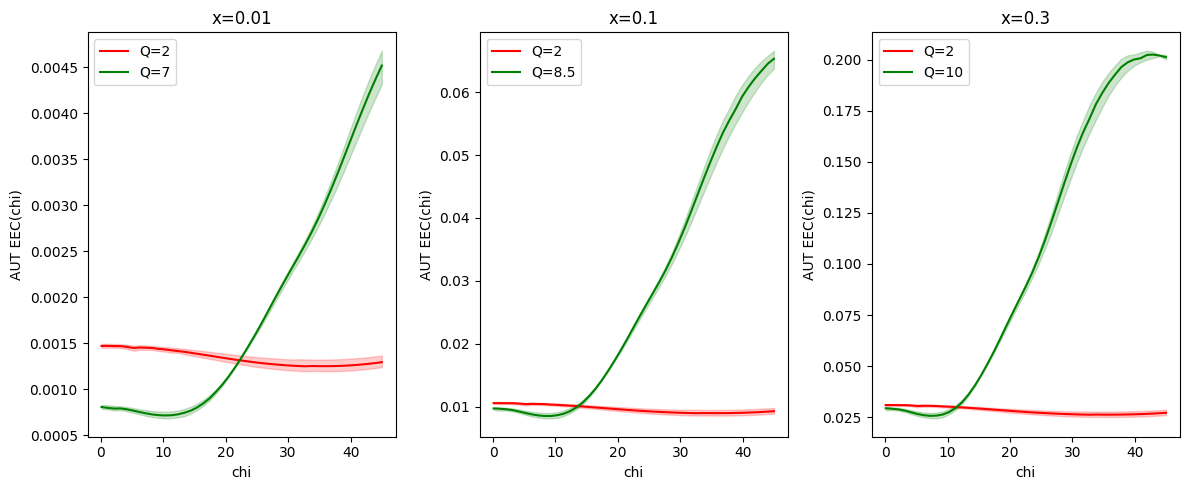

In [11]:
plot_sidis_aut_scan_results(
    scan_results=sidis_scan_results,
    x_q_map=x_q_map,
    title_note=scan_coeffs_path.name,
)


ee EEC AUT Parameter Scan

Test & Warm Up ee AUT

In [12]:
chibar_deg = 30.0
chi_deg = 10.0
chibar = np.deg2rad(chibar_deg)
chi = np.deg2rad(chi_deg)

set_diff_coeffs(0.1, 0.1)

value = Main.EE_EEC_AUT(
    chi=chi,
    chibar=chibar,
    Q=2.0,
    mu=1.0,
    rep=0,
)

warmup_values, warmup_time = Main.EE_EEC_AUT_pmap(
    chi_array=[chi, chi],
    chibar_array=[chibar, chibar],
    Q_array=[2.0, 2.0],
    mu_array=[1.0, 1.0],
    rep=[0, 0],
)

display(value)
display((len(warmup_values), warmup_time))


0.0019460493563440997

(2, 0.151614382)

In [13]:
def _prepare_ee_kinematics(chibar_deg_list, Q_list, chi_deg_array=None):
    if chi_deg_array is None:
        chi_deg_array = np.linspace(chi_deg_range[0], chi_deg_range[1], ee_aut_plot_n_points)

    kinematics = {}
    for chibar_deg in chibar_deg_list:
        chibar = np.deg2rad(chibar_deg)
        zbar = (1 - np.cos(chibar)) / 2

        for Q in Q_list:
            chi_deg_valid = []
            chi_valid = []
            for chi_deg in chi_deg_array:
                chi = np.deg2rad(chi_deg)
                z = (1 - np.cos(chi)) / 2
                if np.sqrt(z) * Q > 7 or np.sqrt(zbar) * Q > 7:
                    continue
                chi_deg_valid.append(float(chi_deg))
                chi_valid.append(float(chi))

            if not chi_valid:
                raise ValueError(f"No valid chi points survived for chibar={chibar_deg:g}, Q={Q:g}")

            chi_array = np.asarray(chi_valid, dtype=float)
            kinematics[(float(chibar_deg), float(Q))] = {
                "chibar_deg": float(chibar_deg),
                "Q": float(Q),
                "chibar": float(chibar),
                "chi_deg": np.asarray(chi_deg_valid, dtype=float),
                "chi_array": chi_array,
                "chibar_array": np.full(chi_array.size, float(chibar), dtype=float),
                "Q_array": np.full(chi_array.size, float(Q), dtype=float),
                "mu_array": np.full(chi_array.size, float(c * Q), dtype=float),
            }
    return kinematics


def _run_ee_central_curve(kin):
    values, _ = Main.EE_EEC_AUT_pmap(
        chi_array=kin["chi_array"],
        chibar_array=kin["chibar_array"],
        Q_array=kin["Q_array"],
        mu_array=kin["mu_array"],
        rep=np.zeros(kin["chi_array"].size, dtype=int),
    )
    return np.asarray(values, dtype=float)


def _run_ee_replica_curves(kin, replica_ids, coeff_grid):
    n_reps = len(replica_ids)
    n_chi = kin["chi_array"].size
    if n_reps == 0:
        return np.empty((0, n_chi), dtype=float)

    coeff_grid = np.asarray(coeff_grid, dtype=float)
    values, _ = Main.EE_EEC_AUT_pmap_with_coeffs(
        chi_array=np.tile(kin["chi_array"], n_reps),
        chibar_array=np.tile(kin["chibar_array"], n_reps),
        Q_array=np.tile(kin["Q_array"], n_reps),
        mu_array=np.tile(kin["mu_array"], n_reps),
        rep=np.repeat(replica_ids, n_chi),
        a_array=np.repeat(coeff_grid[:, 0], n_chi),
        b_array=np.repeat(coeff_grid[:, 1], n_chi),
    )
    return np.asarray(values, dtype=float).reshape(n_reps, n_chi)


def generate_ee_aut_scan_results(*, chibar_deg_list, Q_list, coeffs_path, replica_ids=None, fit_order="LO", chi_deg_array=None, save_plot_data=False):
    if fit_order != "LO":
        raise ValueError("Only LO is currently supported")

    coeff_grid = _read_scan_coeffs(coeffs_path)
    sampled_coeff_grid, sampled_coeff_indices = _sample_coeff_assignments(coeff_grid)
    replica_pool = _normalize_replica_ids(replica_ids)
    sampled_replica_ids = _sample_replica_assignments(replica_pool, len(sampled_coeff_grid))
    scan_label = Path(coeffs_path).stem
    kinematics = _prepare_ee_kinematics(chibar_deg_list, Q_list, chi_deg_array)

    scan_results = {
        "process": "EE_AUT",
        "fit_order": fit_order,
        "scan_label": scan_label,
        "coeffs_path": str(Path(coeffs_path).resolve()),
        "coeff_grid": coeff_grid,
        "sampled_coeff_grid": sampled_coeff_grid,
        "sampled_coeff_indices": sampled_coeff_indices,
        "replica_ids": replica_pool,
        "sampled_replica_ids": sampled_replica_ids,
        "chibar_deg_list": [float(value) for value in chibar_deg_list],
        "Q_list": [float(value) for value in Q_list],
        "by_kinematics": {},
    }

    n_reps = len(sampled_replica_ids)
    for key, kin in kinematics.items():
        n_chi = kin["chi_array"].size
        scan_results["by_kinematics"][key] = {
            **kin,
            "replica_curves": np.empty((n_reps, n_chi), dtype=float),
        }

    total_jobs = len(sampled_replica_ids) * len(kinematics)
    jobs_done = 0
    t0_all = time.perf_counter()
    _print_progress(0, total_jobs, t0_all, "ee AUT parameter draws starting")

    for (chibar_deg, Q), entry in scan_results["by_kinematics"].items():
        for start, stop in _iter_draw_slices(len(sampled_replica_ids)):
            entry["replica_curves"][start:stop] = _run_ee_replica_curves(
                entry,
                sampled_replica_ids[start:stop],
                sampled_coeff_grid[start:stop],
            )
            jobs_done += stop - start
            _print_progress(jobs_done, total_jobs, t0_all, f"ee AUT parameter draws {start + 1}-{stop}/{len(sampled_replica_ids)}, chibar={chibar_deg:g}, Q={Q:g}")

    for entry in scan_results["by_kinematics"].values():
        _apply_percentile_summary(entry, entry["replica_curves"], entry["replica_curves"], "AUT")

    if save_plot_data:
        _save_scan_plot_data(
            scan_results,
            filename="ee_aut.pkl",
            value_prefix="AUT",
            root_keys=["chibar_deg_list", "Q_list", "sampled_coeff_indices", "sampled_coeff_grid", "sampled_replica_ids"],
            entry_keys=["chibar_deg", "Q", "chibar", "chi_deg", "chi_array", "mu_array"],
        )

    total_elapsed = time.perf_counter() - t0_all
    clear_output(wait=True)
    print(
        f"done | ee scan={scan_label} | "
        f"parameter draws={len(sampled_replica_ids)} | fixed JAM replica=0 | "
        f"total elapsed: {_format_seconds(total_elapsed)}"
    )

    return scan_results


def plot_ee_aut_scan_results(*, scan_results, chibar_deg_list, Q_list):
    print(f"Results for {scan_results['fit_order']}")
    print(
        f"scan={scan_results['scan_label']} | "
        f"parameter draws={len(scan_results['sampled_replica_ids'])} | "
        f"fixed JAM replica=0 | central 68%"
    )

    nrows, ncols = 1, len(chibar_deg_list)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * len(chibar_deg_list), 5))
    axes = np.atleast_1d(axes)
    color_arr = ['r', 'g', 'b', 'y', 'orange', 'cyan']

    for ifig, chibar_deg in enumerate(chibar_deg_list):
        ax1 = axes[ifig]
        for icol, Q in enumerate(Q_list):
            entry = scan_results["by_kinematics"][(float(chibar_deg), float(Q))]
            chi_deg = np.asarray(entry["chi_deg"], dtype=float)
            aut_median = np.asarray(entry["AUT_median"], dtype=float)
            aut_lower_68 = np.asarray(entry["AUT_lower_68"], dtype=float)
            aut_upper_68 = np.asarray(entry["AUT_upper_68"], dtype=float)
            color = color_arr[icol % len(color_arr)]

            ax1.plot(chi_deg, aut_median, color=color, label=f'Q={Q:g}')
            ax1.fill_between(chi_deg, aut_lower_68, aut_upper_68, color=color, alpha=0.2)

        ax1.set_xlabel('chi')
        ax1.set_ylabel('AUT EEC(chi)')
        ax1.set_title(f'chibar={chibar_deg:g}')
        ax1.legend()

    plt.tight_layout()
    plt.show()


In [14]:
chibar_deg_list = [1, 15, 30]
Q_list = [3.65, 10.58]

ee_scan_results = generate_ee_aut_scan_results(
    chibar_deg_list=chibar_deg_list,
    Q_list=Q_list,
    coeffs_path=scan_coeffs_path,
    fit_order="LO",
    chi_deg_array=np.linspace(chi_deg_range[0], chi_deg_range[1], ee_aut_plot_n_points),
    save_plot_data=False,
)


done | ee scan=a_b_uniform_area_100 | parameter draws=100 | fixed JAM replica=0 | total elapsed: 24.5s


Results for LO
scan=a_b_uniform_area_100 | parameter draws=100 | fixed JAM replica=0 | central 68%


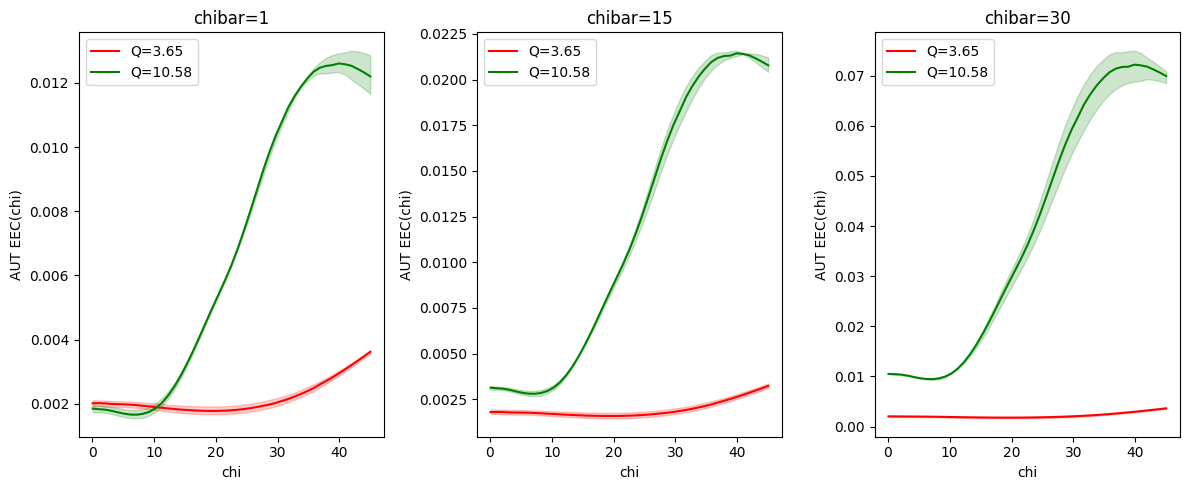

In [15]:
plot_ee_aut_scan_results(
    scan_results=ee_scan_results,
    chibar_deg_list=chibar_deg_list,
    Q_list=Q_list,
)


ee EEC Parameter Scan


In [16]:
print(f"Using ee EEC scan grid from {scan_coeffs_path}")

Using ee EEC scan grid from a_b_uniform_area_100.xlsx


In [17]:
def _prepare_ee_eec_kinematics(Q_list, chi_deg_array=None):
    if chi_deg_array is None:
        chi_deg_array = np.linspace(chi_deg_range[0], chi_deg_range[1], ee_eec_plot_n_points)

    chi_deg_array = np.asarray(chi_deg_array, dtype=float)
    chi_array = np.deg2rad(chi_deg_array)

    kinematics = {}
    for Q in Q_list:
        Q = float(Q)
        npts = len(chi_array)
        kinematics[Q] = {
            "Q": Q,
            "chi_deg": chi_deg_array.copy(),
            "chi_array": chi_array.copy(),
            "Q_array": np.full(npts, Q, dtype=float),
            "mu_array": np.full(npts, c * Q, dtype=float),
        }

    return kinematics


def _run_ee_eec_central_curve(kin):
    values, _ = Main.EE_EEC_pmap(
        chi_array=kin["chi_array"],
        Q_array=kin["Q_array"],
        mu_array=kin["mu_array"],
        rep=np.zeros(kin["chi_array"].size, dtype=int),
    )
    return np.asarray(values, dtype=float)


def _run_ee_eec_replica_curves(kin, replica_ids, coeff_grid):
    n_reps = len(replica_ids)
    n_chi = kin["chi_array"].size
    if n_reps == 0:
        return np.empty((0, n_chi), dtype=float)

    coeff_grid = np.asarray(coeff_grid, dtype=float)
    values, _ = Main.EE_EEC_pmap_with_coeffs(
        chi_array=np.tile(kin["chi_array"], n_reps),
        Q_array=np.tile(kin["Q_array"], n_reps),
        mu_array=np.tile(kin["mu_array"], n_reps),
        rep=np.repeat(replica_ids, n_chi),
        a_array=np.repeat(coeff_grid[:, 0], n_chi),
        b_array=np.repeat(coeff_grid[:, 1], n_chi),
    )
    return np.asarray(values, dtype=float).reshape(n_reps, n_chi)


def generate_ee_eec_scan_results(*, Q_list, coeffs_path, replica_ids=None, fit_order="LO", chi_deg_array=None, save_plot_data=False):
    if fit_order != "LO":
        raise ValueError("Only LO is currently supported")

    coeff_grid = _read_scan_coeffs(coeffs_path)
    sampled_coeff_grid, sampled_coeff_indices = _sample_coeff_assignments(coeff_grid)
    replica_pool = _normalize_replica_ids(replica_ids)
    sampled_replica_ids = _sample_replica_assignments(replica_pool, len(sampled_coeff_grid))
    scan_label = Path(coeffs_path).stem
    kinematics = _prepare_ee_eec_kinematics(Q_list, chi_deg_array=chi_deg_array)

    scan_results = {
        "process": "EE_EEC",
        "fit_order": fit_order,
        "scan_label": scan_label,
        "coeffs_path": str(Path(coeffs_path).resolve()),
        "coeff_grid": coeff_grid,
        "sampled_coeff_grid": sampled_coeff_grid,
        "sampled_coeff_indices": sampled_coeff_indices,
        "replica_ids": replica_pool,
        "sampled_replica_ids": sampled_replica_ids,
        "Q_list": [float(Q) for Q in Q_list],
        "by_kinematics": {},
    }

    n_reps = len(sampled_replica_ids)
    for key, kin in kinematics.items():
        n_chi = kin["chi_array"].size
        scan_results["by_kinematics"][key] = {
            **kin,
            "replica_curves": np.empty((n_reps, n_chi), dtype=float),
        }

    total_jobs = len(sampled_replica_ids) * len(kinematics)
    jobs_done = 0
    t0_all = time.perf_counter()
    _print_progress(0, total_jobs, t0_all, "ee EEC parameter draws starting")

    for (Q, entry) in scan_results["by_kinematics"].items():
        for start, stop in _iter_draw_slices(len(sampled_replica_ids)):
            entry["replica_curves"][start:stop] = _run_ee_eec_replica_curves(
                entry,
                sampled_replica_ids[start:stop],
                sampled_coeff_grid[start:stop],
            )
            jobs_done += stop - start
            _print_progress(jobs_done, total_jobs, t0_all, f"ee EEC parameter draws {start + 1}-{stop}/{len(sampled_replica_ids)}, Q={Q:g}")

    for entry in scan_results["by_kinematics"].values():
        _apply_percentile_summary(entry, entry["replica_curves"], entry["replica_curves"], "EEC")

    if save_plot_data:
        _save_scan_plot_data(
            scan_results,
            filename="ee_eec.pkl",
            value_prefix="EEC",
            root_keys=["Q_list", "sampled_coeff_indices", "sampled_coeff_grid", "sampled_replica_ids"],
            entry_keys=["Q", "chi_deg", "chi_array", "mu_array"],
        )

    total_elapsed = time.perf_counter() - t0_all
    clear_output(wait=True)
    print(
        f"done | ee EEC scan={scan_label} | "
        f"parameter draws={len(sampled_replica_ids)} | fixed JAM replica=0 | "
        f"total elapsed: {_format_seconds(total_elapsed)}"
    )

    return scan_results


def plot_ee_eec_scan_results(*, scan_results, Q_list):
    q_values = [float(Q) for Q in Q_list]
    fig, axes = plt.subplots(1, len(q_values), figsize=(5 * len(q_values), 4.5), sharey=False)
    axes = np.atleast_1d(axes)

    experiment_labels = {
        3.65: "BESIII",
        10.58: "BELLE",
    }

    for ax, Q in zip(axes, q_values):
        entry = scan_results["by_kinematics"][Q]
        chi_deg = np.asarray(entry["chi_deg"], dtype=float)
        median = np.asarray(entry["EEC_median"], dtype=float)
        lower_68 = np.asarray(entry["EEC_lower_68"], dtype=float)
        upper_68 = np.asarray(entry["EEC_upper_68"], dtype=float)

        ax.plot(chi_deg, median, color="#c43c39", lw=2.0)
        ax.fill_between(chi_deg, lower_68, upper_68, color="#c43c39", alpha=0.20)

        experiment = experiment_labels.get(Q, "ee")
        ax.set_title(f"{experiment}, Q={Q:g} GeV")
        ax.set_xlabel("chi [deg]")
        ax.set_ylabel("EEC(chi)")
        ax.grid(alpha=0.25)

    fig.suptitle(
        f"Unpolarized ee EEC scan: scan={scan_results['scan_label']}, parameter draws={len(scan_results['sampled_replica_ids'])}, fixed JAM replica=0, central 68%",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


done | ee EEC scan=a_b_uniform_area_100 | parameter draws=100 | fixed JAM replica=0 | total elapsed: 4.0s


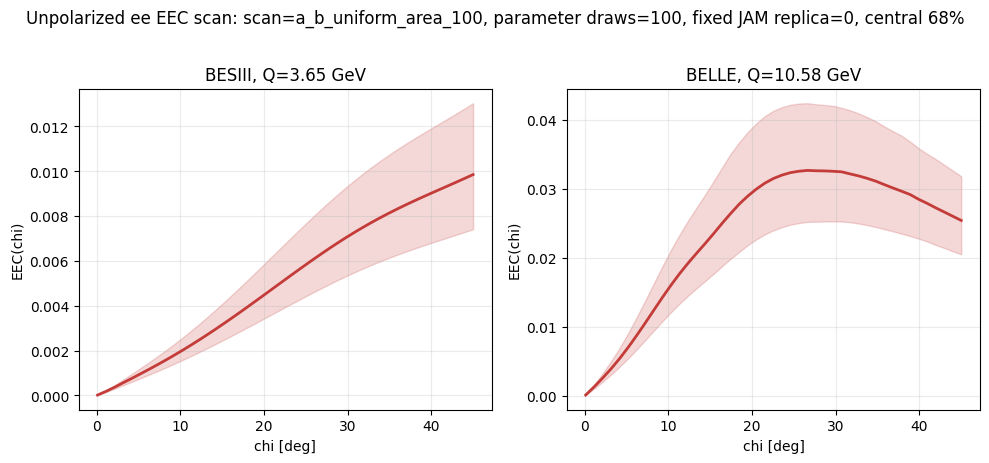

In [18]:
ee_eec_Q_list = [3.65, 10.58]

ee_eec_scan_results = generate_ee_eec_scan_results(
    Q_list=ee_eec_Q_list,
    coeffs_path=scan_coeffs_path,
    chi_deg_array=np.linspace(chi_deg_range[0], chi_deg_range[1], ee_eec_plot_n_points),
    save_plot_data=False,
)

plot_ee_eec_scan_results(
    scan_results=ee_eec_scan_results,
    Q_list=ee_eec_Q_list,
)


SIDIS EEC Replica Prediction


In [19]:
fit_name = globals().get("fit_name", "Default")
N_cores = int(globals().get("N_cores", 16))
c = float(globals().get("c", 0.5))
sidis_plot_n_points = int(globals().get("sidis_plot_n_points", 45))
fitting_root = globals().get("fitting_root", "../")
card_name = globals().get("card_name", fit_name.removesuffix(".jl"))

Main.eval('using Distributed')
existing_workers = list(Main.eval('workers()'))
if existing_workers:
    Main.eval('rmprocs(workers())')
Main.eval(f'addprocs({N_cores})')


def include(name):
    path = os.path.join(fitting_root, name)
    Main.eval(f'@everywhere include(raw"{path}")')


# Rebuild the minimal Julia state needed for SIDIS EEC on a fresh worker pool.
include(f"Cards/{card_name}.jl")
include("Collinear_PDF/pdf.jl")
include("Core/constants.jl")
include("Core/strong coupling.jl")
include("Numerical/FastGK.jl")
include("DiFF_EEC/DiFF_EEC.jl")
include("Splitting/moments.jl")
include("DiFF_EEC/DiFF_EEC_own.jl")
include("Processes/SIDIS/SIDIS_EEC.jl")

Main.eval("""@everywhere begin
function _sidis_eec_batch_size(n::Integer)
    return max(1, min(64, cld(n, max(nworkers(), 1) * 4)))
end

function _sidis_eec_quiet_set_lhapdf(i_set::Int64, name::String, i_member::Int64)
    redirect_stdout(devnull) do
        redirect_stderr(devnull) do
            set_lhapdf(i_set, name, i_member)
        end
    end
    return nothing
end

function SIDIS_EEC_pmap_with_params_and_pdfmember_ascii(; chi_array::AbstractVector, x_array::AbstractVector, Q_array::AbstractVector, mu_array::AbstractVector, pdf_member_array::AbstractVector, p0_array::AbstractVector, p1_array::AbstractVector, p2_array::AbstractVector)
    n = length(chi_array)
    length(x_array) == n || throw(ArgumentError("x_array must have the same length as chi_array"))
    length(Q_array) == n || throw(ArgumentError("Q_array must have the same length as chi_array"))
    length(mu_array) == n || throw(ArgumentError("mu_array must have the same length as chi_array"))
    length(pdf_member_array) == n || throw(ArgumentError("pdf_member_array must have the same length as chi_array"))
    length(p0_array) == n || throw(ArgumentError("p0_array must have the same length as chi_array"))
    length(p1_array) == n || throw(ArgumentError("p1_array must have the same length as chi_array"))
    length(p2_array) == n || throw(ArgumentError("p2_array must have the same length as chi_array"))

    args_vec = collect(zip(chi_array, x_array, Q_array, mu_array, Int.(pdf_member_array), Float64.(p0_array), Float64.(p1_array), Float64.(p2_array)))

    predictions = nothing
    t = @elapsed begin
        predictions = pmap(args_vec; batch_size = _sidis_eec_batch_size(length(args_vec))) do (chi, x, Q, mu, pdf_member_i, p0_i, p1_i, p2_i)
            Core.eval(Main, :(p0 = $(p0_i)))
            Core.eval(Main, :(p1 = $(p1_i)))
            Core.eval(Main, :(p2 = $(p2_i)))
            _sidis_eec_quiet_set_lhapdf(0, pdf_dict_array[1]["pdfset_name"], pdf_member_i)
            SIDIS_EEC(chi = chi, x = x, Q = Q, μ = mu)
        end
    end

    return predictions, t
end
end""")

sidis_eec_available_scale_configs = {
    "Q": {
        "mu_factor": float(c),
        "params_path": Path("../../DiFF/EECs_AUT_code/JAMDiFF_library/EEC_DiFF_replicas/params_LO_Q.xlsx"),
    },
    "2Q": {
        "mu_factor": float(2 * c),
        "params_path": Path("../../DiFF/EECs_AUT_code/JAMDiFF_library/EEC_DiFF_replicas/params_LO_2Q.xlsx"),
    },
    "Q/2": {
        "mu_factor": float(c / 2),
        "params_path": Path("../../DiFF/EECs_AUT_code/JAMDiFF_library/EEC_DiFF_replicas/params_LO_Qover2.xlsx"),
    },
}
sidis_eec_scale_labels = list(globals().get("sidis_eec_scale_labels", ["Q", "2Q", "Q/2"]))
unknown_sidis_eec_scale_labels = [label for label in sidis_eec_scale_labels if label not in sidis_eec_available_scale_configs]
if unknown_sidis_eec_scale_labels:
    raise ValueError(
        f"Unknown SIDIS EEC scale labels: {unknown_sidis_eec_scale_labels}. Available labels: {list(sidis_eec_available_scale_configs)}"
    )
if not sidis_eec_scale_labels:
    raise ValueError("sidis_eec_scale_labels must contain at least one scale label")
sidis_eec_scale_configs = {
    label: sidis_eec_available_scale_configs[label]
    for label in sidis_eec_scale_labels
}
sidis_eec_params_path = sidis_eec_scale_configs[sidis_eec_scale_labels[0]]["params_path"]
sidis_eec_central_params = np.asarray([0.035, 150.0, 10.1], dtype=float)
try:
    sidis_eec_pdfset_name = sidis_ct18_pdfset_name
except NameError:
    sidis_eec_pdfset_name = str(Main.eval('pdf_dict_array[1]["pdfset_name"]'))

sidis_ct18_positive_member_ids = np.asarray([0], dtype=int)

print(f"SIDIS EEC worker pool reset to {len(Main.eval('workers()'))} worker(s).")
print(f"Using unpolarized PDF set {sidis_eec_pdfset_name} with fixed CT18 member 0.")
print(f"Selected SIDIS EEC scale labels: {sidis_eec_scale_labels}")
print(f"Available SIDIS EEC scale labels: {list(sidis_eec_available_scale_configs)}")
print("Using SIDIS EEC scale branches:")
for scale_label, cfg in sidis_eec_scale_configs.items():
    print(f"  {scale_label}: mu/Q={cfg['mu_factor']:.3g}, params={cfg['params_path']}")


      From worker 3:	Thanks for using LHAPDF 6.5.5. Please make sure to cite the paper:
      From worker 3:	  Eur.Phys.J. C75 (2015) 3, 132  (http://arxiv.org/abs/1412.7420)
      From worker 2:	Thanks for using LHAPDF 6.5.5. Please make sure to cite the paper:
      From worker 2:	  Eur.Phys.J. C75 (2015) 3, 132  (http://arxiv.org/abs/1412.7420)
      From worker 5:	Thanks for using LHAPDF 6.5.5. Please make sure to cite the paper:
      From worker 5:	  Eur.Phys.J. C75 (2015) 3, 132  (http://arxiv.org/abs/1412.7420)
      From worker 8:	Thanks for using LHAPDF 6.5.5. Please make sure to cite the paper:
      From worker 8:	  Eur.Phys.J. C75 (2015) 3, 132  (http://arxiv.org/abs/1412.7420)
      From worker 6:	Thanks for using LHAPDF 6.5.5. Please make sure to cite the paper:
      From worker 6:	  Eur.Phys.J. C75 (2015) 3, 132  (http://arxiv.org/abs/1412.7420)
      From worker 7:	Thanks for using LHAPDF 6.5.5. Please make sure to cite the paper:
      From worker 7:	  Eur.Phys.J. C7

      From worker 12:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/CT18NLO_mc/CT18NLO_mc_0000.dat
      From worker 12:	CT18NLO_mc PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 16:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/CT18NLO_mc/CT18NLO_mc_0000.dat
      From worker 16:	CT18NLO_mc PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 13:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/CT18NLO_mc/CT18NLO_mc_0000.dat
      From worker 13:	CT18NLO_mc PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 10:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/CT18NLO_mc/CT18NLO_mc_0000.dat
      From worker 10:	CT18NLO_mc PDF set, member #0, version 1; LHAPDF ID = 14400
      From worker 17:	LHAPDF 6.5.5 loading /home/maxzhang/UCLA_QCD_fitter/installation/share/LHAPDF/CT18NLO_mc/CT18NLO_mc_0000.dat
      From worker

In [20]:
import time
try:
    from IPython.display import clear_output
except Exception:
    def clear_output(*args, **kwargs):
        return None

if 'PERCENTILE_LEVELS' not in globals():
    PERCENTILE_LEVELS = np.asarray([16.0, 50.0, 84.0], dtype=float)

if '_sample_sidis_ct18_members' not in globals():
    def _sample_sidis_ct18_members(n):
        n = int(n)
        if n <= 0:
            return np.empty(0, dtype=int)
        return np.zeros(n, dtype=int)

if '_format_seconds' not in globals():
    def _format_seconds(seconds):
        seconds = max(float(seconds), 0.0)
        if seconds < 60:
            return f"{seconds:.1f}s"
        minutes, sec = divmod(seconds, 60.0)
        if minutes < 60:
            return f"{int(minutes)}m {sec:04.1f}s"
        hours, minutes = divmod(minutes, 60.0)
        return f"{int(hours)}h {int(minutes):02d}m {sec:04.1f}s"

if '_print_progress' not in globals():
    def _print_progress(done, total, t0, label):
        total = max(int(total), 1)
        done = int(done)
        elapsed = time.perf_counter() - t0
        if done <= 0:
            remaining_text = "0.0s"
        else:
            remaining = elapsed * max(total - done, 0) / max(done, 1)
            remaining_text = _format_seconds(remaining)
        clear_output(wait=True)
        print(f"[{done}/{total}] {label} | remaining={remaining_text}", flush=True)

if '_resolve_x_q_inputs' not in globals():
    def _resolve_x_q_inputs(*, x_list=None, Q_list=None, x_q_map=None):
        if x_q_map is not None:
            x_values = [float(x) for x in x_q_map.keys()]
            x_to_q = {float(x): [float(Q) for Q in x_q_map[x]] for x in x_q_map.keys()}
        else:
            if x_list is None or Q_list is None:
                raise ValueError("Provide either x_q_map or both x_list and Q_list")
            x_values = [float(x) for x in x_list]
            q_values = [float(Q) for Q in Q_list]
            x_to_q = {x: list(q_values) for x in x_values}
        x_q_pairs = [(x, Q) for x in x_values for Q in x_to_q[x]]
        return x_values, x_to_q, x_q_pairs

if '_prepare_sidis_kinematics' not in globals():
    def _prepare_sidis_kinematics(*, x_list=None, Q_list=None, x_q_map=None, chi_deg_array=None):
        if chi_deg_array is None:
            chi_deg_array = np.linspace(chi_deg_range[0], chi_deg_range[1], sidis_plot_n_points)
        x_values, x_to_q, x_q_pairs = _resolve_x_q_inputs(x_list=x_list, Q_list=Q_list, x_q_map=x_q_map)
        kinematics = {}
        for x, Q in x_q_pairs:
            chi_deg_valid = []
            chi_valid = []
            for chi_deg in chi_deg_array:
                chi = np.deg2rad(chi_deg)
                z = (1 - np.cos(chi)) / 2
                if np.sqrt(z) * Q > 7:
                    continue
                chi_deg_valid.append(float(chi_deg))
                chi_valid.append(float(chi))
            if not chi_valid:
                raise ValueError(f"No valid chi points survived for x={x:.2f}, Q={Q:g}")
            chi_array = np.asarray(chi_valid, dtype=float)
            kinematics[(float(x), float(Q))] = {
                "x": float(x),
                "Q": float(Q),
                "chi_deg": np.asarray(chi_deg_valid, dtype=float),
                "chi_array": chi_array,
                "mu_array": np.full(chi_array.size, float(c * Q), dtype=float),
                "x_array": np.full(chi_array.size, float(x), dtype=float),
                "Q_array": np.full(chi_array.size, float(Q), dtype=float),
            }
        return x_values, x_to_q, kinematics

if '_save_plot_data' not in globals():
    def _save_plot_data(filename, payload):
        raise RuntimeError("This parameter-only notebook does not write pkl plot data.")

if '_apply_percentile_summary' not in globals():
    def _apply_percentile_summary(entry, samples, fallback_samples, prefix):
        samples = np.asarray(samples, dtype=float)
        if samples.size:
            summary_samples = samples
        else:
            summary_samples = np.asarray(fallback_samples, dtype=float)
        if summary_samples.ndim != 2 or summary_samples.shape[0] == 0:
            raise ValueError("No sample curves available for percentile summary")
        percentile_16, percentile_50, percentile_84 = np.percentile(
            summary_samples,
            PERCENTILE_LEVELS,
            axis=0,
        )
        entry[f"{prefix}_percentile_16"] = np.asarray(percentile_16, dtype=float)
        entry[f"{prefix}_percentile_50"] = np.asarray(percentile_50, dtype=float)
        entry[f"{prefix}_percentile_84"] = np.asarray(percentile_84, dtype=float)
        entry[f"{prefix}_median"] = np.asarray(percentile_50, dtype=float)
        entry[f"{prefix}_lower_68"] = np.asarray(percentile_16, dtype=float)
        entry[f"{prefix}_upper_68"] = np.asarray(percentile_84, dtype=float)
        entry["n_members"] = int(summary_samples.shape[0])


def _read_sidis_eec_parameter_members(path):
    path = Path(path)
    df = pd.read_excel(path)
    if df.shape[0] < 3:
        raise ValueError(f"Expected three parameter rows in {path}")

    param_columns = [col for col in df.columns if str(col).startswith("params")]
    if not param_columns:
        raise ValueError(f"No parameter replica columns found in {path}")

    values = df.loc[:2, param_columns].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float).T
    if np.isnan(values).any():
        raise ValueError(f"Found non-numeric parameter replica values in {path}")

    member_ids = np.asarray([int(str(col).removeprefix("params")) for col in param_columns], dtype=int)
    return values, member_ids


def _sample_sidis_eec_parameter_assignments(parameter_members, parameter_member_ids, n_assignments=None):
    parameter_members = np.asarray(parameter_members, dtype=float)
    parameter_member_ids = np.asarray(parameter_member_ids, dtype=int)
    if parameter_members.shape[0] != parameter_member_ids.size:
        raise ValueError("parameter_members and parameter_member_ids must have the same length")
    return parameter_members.copy(), parameter_member_ids.copy()


def _resolve_sidis_eec_pdf_member_ids(n_draws, pdf_member_ids=None):
    return np.zeros(int(n_draws), dtype=int)


def _normalize_sidis_eec_scale_configs(scale_configs=None):
    if scale_configs is None:
        scale_configs = sidis_eec_scale_configs

    normalized = []
    for scale_label, cfg in scale_configs.items():
        if "params_path" not in cfg or "mu_factor" not in cfg:
            raise ValueError(f"Scale config {scale_label} must provide params_path and mu_factor")

        params_path = Path(cfg["params_path"])
        mu_factor = float(cfg["mu_factor"])
        if mu_factor <= 0:
            raise ValueError(f"Scale config {scale_label} must have positive mu_factor")

        normalized.append((str(scale_label), {
            "params_path": params_path,
            "mu_factor": mu_factor,
        }))

    if not normalized:
        raise ValueError("At least one SIDIS EEC scale config is required")
    return normalized


def _resolve_sidis_eec_pdf_member_map(scale_labels, draws_per_scale, pdf_member_ids=None):
    scale_labels = [str(label) for label in scale_labels]
    draws_per_scale = int(draws_per_scale)

    if pdf_member_ids is None:
        return {
            scale_label: _resolve_sidis_eec_pdf_member_ids(draws_per_scale)
            for scale_label in scale_labels
        }

    if isinstance(pdf_member_ids, dict):
        extra = sorted(set(pdf_member_ids) - set(scale_labels))
        if extra:
            raise ValueError(f"Unexpected SIDIS EEC scale labels in pdf_member_ids: {extra}")

        return {
            scale_label: _resolve_sidis_eec_pdf_member_ids(draws_per_scale, pdf_member_ids.get(scale_label))
            for scale_label in scale_labels
        }

    pdf_member_ids = np.asarray(pdf_member_ids, dtype=int)
    expected = draws_per_scale * len(scale_labels)
    if pdf_member_ids.ndim != 1:
        raise ValueError("pdf_member_ids must be one-dimensional")
    if pdf_member_ids.size != expected:
        raise ValueError(
            f"Expected {expected} PDF members for {len(scale_labels)} scales and {draws_per_scale} draws per scale, got {pdf_member_ids.size}"
        )

    pdf_member_map = {}
    offset = 0
    for scale_label in scale_labels:
        pdf_member_map[scale_label] = _resolve_sidis_eec_pdf_member_ids(
            draws_per_scale,
            pdf_member_ids[offset:offset + draws_per_scale],
        )
        offset += draws_per_scale
    return pdf_member_map


def _run_sidis_eec_curve(kin, pdf_member, params, mu_factor):
    params = np.asarray(params, dtype=float)
    mu_array = np.full(kin["chi_array"].size, float(mu_factor * kin["Q"]), dtype=float)
    values, _ = Main.SIDIS_EEC_pmap_with_params_and_pdfmember_ascii(
        chi_array=kin["chi_array"],
        x_array=kin["x_array"],
        Q_array=kin["Q_array"],
        mu_array=mu_array,
        pdf_member_array=np.full(kin["chi_array"].size, int(pdf_member), dtype=int),
        p0_array=np.full(kin["chi_array"].size, float(params[0]), dtype=float),
        p1_array=np.full(kin["chi_array"].size, float(params[1]), dtype=float),
        p2_array=np.full(kin["chi_array"].size, float(params[2]), dtype=float),
    )
    return np.asarray(values, dtype=float)


def _save_sidis_eec_plot_data(scan_results):
    payload = {
        "card_name": card_name,
        "process": scan_results["process"],
        "fit_order": scan_results["fit_order"],
        "params_path": scan_results["params_path"],
        "scale_configs": scan_results["scale_configs"],
        "draws_per_scale": int(scan_results["draws_per_scale"]),
        "pdfset_name": scan_results["pdfset_name"],
        "pdf_member_ids": np.asarray(scan_results["pdf_member_ids"], dtype=int),
        "parameter_member_ids_by_scale": {
            scale_label: np.asarray(member_ids, dtype=int)
            for scale_label, member_ids in scan_results["parameter_member_ids_by_scale"].items()
        },
        "sampled_scale_labels": list(scan_results["sampled_scale_labels"]),
        "sampled_parameter_member_ids": np.asarray(scan_results["sampled_parameter_member_ids"], dtype=int),
        "central_params": np.asarray(scan_results["central_params"], dtype=float),
        "percentiles": PERCENTILE_LEVELS.copy(),
        "x_values": list(scan_results["x_values"]),
        "x_to_q": {float(x): [float(Q) for Q in q_values] for x, q_values in scan_results["x_to_q"].items()},
        "by_kinematics": {},
    }

    for key, entry in scan_results["by_kinematics"].items():
        payload["by_kinematics"][key] = {
            "x": float(entry["x"]),
            "Q": float(entry["Q"]),
            "chi_deg": np.asarray(entry["chi_deg"], dtype=float),
            "chi_array": np.asarray(entry["chi_array"], dtype=float),
            "mu_array": np.asarray(entry["mu_array"], dtype=float),
            "mu_arrays_by_scale": {
                scale_label: np.asarray(mu_array, dtype=float)
                for scale_label, mu_array in entry["mu_arrays_by_scale"].items()
            },
            "central_curve": np.asarray(entry["central_curve"], dtype=float),
            "percentile_16": np.asarray(entry["EEC_percentile_16"], dtype=float),
            "percentile_50": np.asarray(entry["EEC_percentile_50"], dtype=float),
            "percentile_84": np.asarray(entry["EEC_percentile_84"], dtype=float),
            "median": np.asarray(entry["EEC_median"], dtype=float),
            "lower_68": np.asarray(entry["EEC_lower_68"], dtype=float),
            "upper_68": np.asarray(entry["EEC_upper_68"], dtype=float),
            "n_members": int(entry["n_members"]),
        }

    path = _save_plot_data("sidis_eec.pkl", payload)
    scan_results["plot_data_path"] = str(path)
    return path


def generate_sidis_eec_results(*, x_list=None, Q_list=None, x_q_map=None, scale_configs=None, draws_per_scale=None, pdf_member_ids=None, fit_order="LO", chi_deg_array=None, save_plot_data=False):
    if fit_order != "LO":
        raise ValueError("Only LO is currently supported")

    normalized_scale_configs = _normalize_sidis_eec_scale_configs(scale_configs)
    if draws_per_scale is not None:
        raise ValueError("draws_per_scale is not used in parameter-only mode; all parameter members are used once")

    scale_labels = [scale_label for scale_label, _ in normalized_scale_configs]

    scale_draws = []
    draw_counts = []
    parameter_member_ids_by_scale = {}
    flattened_pdf_members = []
    flattened_parameter_member_ids = []
    flattened_scale_labels = []

    for scale_label, cfg in normalized_scale_configs:
        parameter_members, parameter_member_ids = _read_sidis_eec_parameter_members(cfg["params_path"])
        parameter_member_ids_by_scale[scale_label] = parameter_member_ids
        sampled_parameter_members, sampled_parameter_member_ids = _sample_sidis_eec_parameter_assignments(
            parameter_members,
            parameter_member_ids,
        )
        scale_pdf_members = np.zeros(sampled_parameter_member_ids.size, dtype=int)
        draw_counts.append(sampled_parameter_member_ids.size)

        scale_draws.append({
            "scale_label": scale_label,
            "mu_factor": float(cfg["mu_factor"]),
            "params_path": str(cfg["params_path"].resolve()),
            "sampled_parameter_members": np.asarray(sampled_parameter_members, dtype=float),
            "sampled_parameter_member_ids": np.asarray(sampled_parameter_member_ids, dtype=int),
            "pdf_member_ids": scale_pdf_members,
        })
        flattened_pdf_members.extend(scale_pdf_members.tolist())
        flattened_parameter_member_ids.extend(sampled_parameter_member_ids.tolist())
        flattened_scale_labels.extend([scale_label] * sampled_parameter_member_ids.size)

    total_draws = len(flattened_scale_labels)
    if total_draws <= 0:
        raise ValueError("No SIDIS EEC draws were constructed")
    draws_per_scale = draw_counts[0]
    if any(count != draws_per_scale for count in draw_counts):
        raise ValueError("All SIDIS EEC scale branches must have the same number of parameter members")

    x_values, x_to_q, kinematics = _prepare_sidis_kinematics(
        x_list=x_list,
        Q_list=Q_list,
        x_q_map=x_q_map,
        chi_deg_array=chi_deg_array,
    )

    resolved_scale_configs = {
        scale_label: {
            "params_path": cfg["params_path"],
            "mu_factor": float(cfg["mu_factor"]),
        }
        for scale_label, cfg in normalized_scale_configs
    }

    scan_results = {
        "process": "SIDIS_EEC",
        "fit_order": fit_order,
        "params_path": str(sidis_eec_params_path.resolve()),
        "scale_configs": {
            scale_label: {
                "params_path": str(cfg["params_path"].resolve()),
                "mu_factor": float(cfg["mu_factor"]),
            }
            for scale_label, cfg in normalized_scale_configs
        },
        "draws_per_scale": draws_per_scale,
        "pdfset_name": sidis_eec_pdfset_name,
        "pdf_member_ids": np.asarray(flattened_pdf_members, dtype=int),
        "parameter_member_ids_by_scale": parameter_member_ids_by_scale,
        "sampled_scale_labels": flattened_scale_labels,
        "sampled_parameter_member_ids": np.asarray(flattened_parameter_member_ids, dtype=int),
        "central_params": sidis_eec_central_params.copy(),
        "x_values": x_values,
        "x_to_q": x_to_q,
        "by_kinematics": {},
    }

    for key, kin in kinematics.items():
        n_chi = kin["chi_array"].size
        mu_arrays_by_scale = {
            scale_label: np.full(n_chi, float(cfg["mu_factor"] * kin["Q"]), dtype=float)
            for scale_label, cfg in resolved_scale_configs.items()
        }
        scan_results["by_kinematics"][key] = {
            **kin,
            "mu_array": mu_arrays_by_scale[scale_labels[0]].copy(),
            "mu_arrays_by_scale": mu_arrays_by_scale,
            "central_curve": np.full(n_chi, np.nan, dtype=float),
            "replica_curves": np.empty((total_draws, n_chi), dtype=float),
        }

    total_jobs = max(len(kinematics) * total_draws, 1)
    jobs_done = 0
    t0_all = time.perf_counter()
    _print_progress(0, total_jobs, t0_all, f"SIDIS EEC parameter draws starting | scales={', '.join(scale_labels)}")

    global_index = 0
    for scale_draw in scale_draws:
        scale_label = scale_draw["scale_label"]
        mu_factor = float(scale_draw["mu_factor"])
        sampled_parameter_members = scale_draw["sampled_parameter_members"]
        sampled_parameter_member_ids = scale_draw["sampled_parameter_member_ids"]
        scale_pdf_members = scale_draw["pdf_member_ids"]

        for idraw, params in enumerate(sampled_parameter_members):
            pdf_member = int(scale_pdf_members[idraw])
            parameter_member_id = int(sampled_parameter_member_ids[idraw])
            for (x, Q), entry in scan_results["by_kinematics"].items():
                entry["replica_curves"][global_index] = _run_sidis_eec_curve(entry, pdf_member, params, mu_factor)
                jobs_done += 1
                _print_progress(
                    jobs_done,
                    total_jobs,
                    t0_all,
                    f"SIDIS EEC scale={scale_label}, parameter draw={idraw + 1}/{len(sampled_parameter_members)}, fixed pdf=0, param={parameter_member_id}, x={x:.2f}, Q={Q:g}",
                )
            global_index += 1

    for entry in scan_results["by_kinematics"].values():
        members = entry["replica_curves"]
        _apply_percentile_summary(entry, members, members, "EEC")
        entry["central_curve"] = np.asarray(entry["EEC_median"], dtype=float)

    if save_plot_data:
        _save_sidis_eec_plot_data(scan_results)

    total_elapsed = time.perf_counter() - t0_all
    clear_output(wait=True)
    print(
        f"done | SIDIS EEC scales={', '.join(scale_labels)} | draws/scale={draws_per_scale} | total curves={total_draws} | "
        f"parameter pool={sum(len(ids) for ids in parameter_member_ids_by_scale.values())} | fixed CT18 member=0 | "
        f"total elapsed: {_format_seconds(total_elapsed)}"
    )

    return scan_results


def plot_sidis_eec_results(*, scan_results, x_list=None, Q_list=None, x_q_map=None, title_note=None):
    scale_labels = list(scan_results["scale_configs"].keys())
    print(
        f"SIDIS EEC | scales={', '.join(scale_labels)} | draws/scale={scan_results['draws_per_scale']} | "
        f"total curves={len(scan_results['sampled_parameter_member_ids'])} | "
        f"parameter pool={sum(len(ids) for ids in scan_results['parameter_member_ids_by_scale'].values())} | "
        f"fixed CT18 member=0 | quantiles 16/50/84"
    )
    if title_note is not None:
        print(title_note)

    x_values, x_to_q, _ = _resolve_x_q_inputs(x_list=x_list, Q_list=Q_list, x_q_map=x_q_map)
    fig, axes = plt.subplots(1, len(x_values), figsize=(4 * len(x_values), 5))
    axes = np.atleast_1d(axes)
    color_arr = ['r', 'g', 'b', 'y', 'orange', 'cyan']

    for ifig, x in enumerate(x_values):
        ax1 = axes[ifig]
        for icol, Q in enumerate(x_to_q[x]):
            entry = scan_results["by_kinematics"][(float(x), float(Q))]
            chi_deg = np.asarray(entry["chi_deg"], dtype=float)
            median = np.asarray(entry["EEC_median"], dtype=float)
            lower_68 = np.asarray(entry["EEC_lower_68"], dtype=float)
            upper_68 = np.asarray(entry["EEC_upper_68"], dtype=float)
            color = color_arr[icol % len(color_arr)]

            ax1.plot(chi_deg, median, color=color, label=f'Q={Q:g}')
            ax1.fill_between(chi_deg, lower_68, upper_68, color=color, alpha=0.2)

        ax1.set_xlabel('chi')
        ax1.set_ylabel('EEC(chi)')
        ax1.set_title(f'x={x}')
        ax1.legend()

    plt.tight_layout()
    plt.show()


done | SIDIS EEC scales=Q | draws/scale=150 | total curves=150 | parameter pool=150 | fixed CT18 member=0 | total elapsed: 9.2s
SIDIS EEC | scales=Q | draws/scale=150 | total curves=150 | parameter pool=150 | fixed CT18 member=0 | quantiles 16/50/84
selected scales: Q | chi range: [0.1, 45] deg


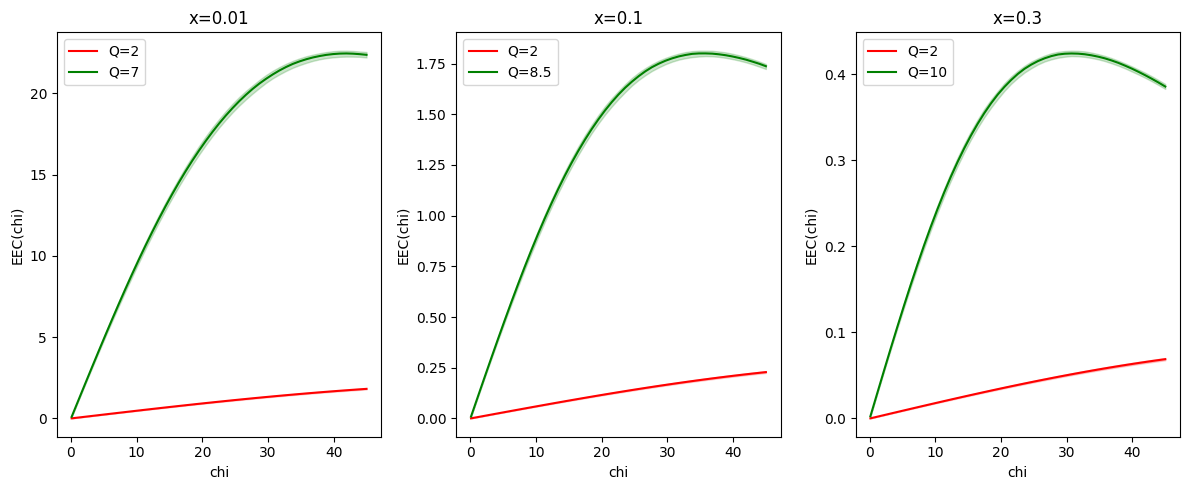

In [21]:
sidis_eec_x_q_map = globals().get(
    "x_q_map",
    {
        0.01: [2.0, 7.0],
        0.1: [2.0, 8.5],
        0.3: [2.0, 10.0],
    },
)

sidis_eec_results = generate_sidis_eec_results(
    x_q_map=sidis_eec_x_q_map,
    scale_configs=sidis_eec_scale_configs,
    chi_deg_array=np.linspace(
        chi_deg_range[0],
        chi_deg_range[1],
        globals().get("sidis_plot_n_points", 45),
    ),
    save_plot_data=False,
)

plot_sidis_eec_results(
    scan_results=sidis_eec_results,
    x_q_map=sidis_eec_x_q_map,
    title_note=(
        f"selected scales: {', '.join(sidis_eec_scale_labels)} | "
        f"chi range: [{chi_deg_range[0]:g}, {chi_deg_range[1]:g}] deg"
    ),
)
